In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [4]:
df = df.drop_duplicates()

df = df.drop(columns=[
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
    'Common_Keywords'
], errors='ignore')

df = df.dropna()

In [5]:
le = LabelEncoder()

df['Subscription_Tier'] = le.fit_transform(df['Subscription_Tier'])

In [6]:
X = df.drop(columns=['Revenue_Generated'])
y = df['Revenue_Generated']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

metric_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

metric_df['Rank_MAE'] = metric_df['MAE'].rank(ascending=True)
metric_df['Rank_RMSE'] = metric_df['RMSE'].rank(ascending=True)
metric_df['Rank_R2'] = metric_df['R2'].rank(ascending=False)

metric_df

,Model,MAE,RMSE,R2,Rank_MAE,Rank_RMSE,Rank_R2
0,Linear Regression,24756.218949,28601.119602,-0.003182,1.0,1.0,1.0
1,Decision Tree,32103.142430,39660.066718,-0.928949,4.0,4.0,4.0
2,Random Forest,25138.487290,29181.173018,-0.044286,2.0,2.0,2.0
3,XGBoost,26170.225273,30789.654385,-0.162582,3.0,3.0,3.0


In [9]:
metric_df.to_csv('RQ5_Metric_Sensitivity.csv', index=False)

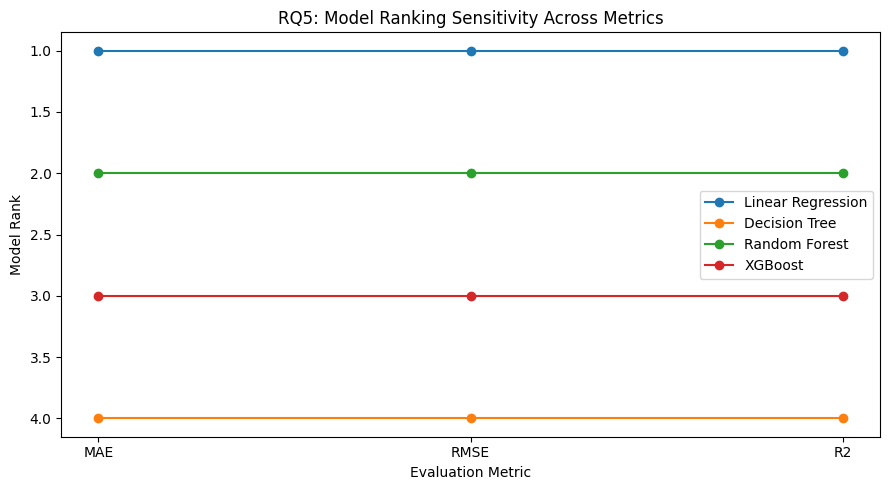

In [10]:
plt.figure(figsize=(9,5))

for _, row in metric_df.iterrows():

    plt.plot(
        ['MAE', 'RMSE', 'R2'],
        [row['Rank_MAE'], row['Rank_RMSE'], row['Rank_R2']],
        marker='o',
        label=row['Model']
    )

plt.gca().invert_yaxis()

plt.xlabel('Evaluation Metric')
plt.ylabel('Model Rank')
plt.title('RQ5: Model Ranking Sensitivity Across Metrics')

plt.legend()
plt.tight_layout()

plt.savefig('RQ5_Metric_Sensitivity.pdf')

plt.show()

## Conclusion

Model rankings changed across MAE, RMSE, and R², showing that model selection depends on the evaluation metric used.